# SrVO$_{3}$

SrVO$_{3}$ adopts the ideal cubic perovskite structure, with corner-sharing VO$_{6}$ octahedra and a nominal V$^{4+}$ ($3d^{1}$) configuration. The low-energy electronic structure is dominated by the V $t_{2g}$ manifold, which forms a moderately correlated metallic state. SrVO$_{3}$ is often used as a benchmark system for studying dynamical correlations because it exhibits clear separation between coherent quasiparticle states near the Fermi level and incoherent Hubbard sidebands in photoemission experiments. While DFT correctly predicts a metallic state, it significantly overestimates the bandwidth and fails to reproduce the observed mass renormalization and spectral weight redistribution. Going beyond DFT with DFT+DMFT incorporates local Coulomb interactions and frequency-dependent self-energies, yielding a quantiative desciption of the electronic spectrum and quasiparticle properties in excellent agreement with experiment.

### 🧪 Exercise 0: Import Modest and Load the DFT data
Load the ``triqs_modest`` module, use the function ``one_body_elements_from_dft_converter`` to load in the HDF5 which was produced by the Wien2k DFT converter in ``srvo3/srvo3.h5``.

> 💡 **Tip:** The function ``one_body_elements_from_dft_converter`` returns the target density and the one-body elements.

Print both the target electron density and the one_body_elements and pause for a moment to see if this information makes sense for SrVO$_{3}$.

In [3]:
import triqs_modest as modest

target_density, obe = modest.one_body_elements_from_dft_converter("srvo3/srvo3.h5")
print(f"target_density= {round(target_density)}e- ( 6e- x 3 O + 1e- x 1 V = 19e-)\n")
print(obe)

target_density= 19e- ( 6e- x 3 O + 1e- x 1 V = 19e-)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 21
      Represented on a fixed grid of 35 points.
      Shape of H[k_idx, σ, ν, ν'] = [35, 1, 21, 21]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 3
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   3
             a:   0
        irreps: [1, 1, 1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [35, 1, 3, 21]
  IBZ = true
    [I]rreduicible [B]rillouin [Z]one symmetry operations from the DFT code [ibz_symmetry_ops]
      Number of symmetry ops: 48
      Number of rotations per op: 1



#### 🔎 Explanation of the OBE

We are studying SrVO$_{3}$ within a large-energy window which fully includes the hybridizaition between the O($2p$) and V($3d$) states. The ``OneBodyElementsOnGrid`` is composed of four pieces that represent the one-body physics that is obtained from DFT and will be used in the DMFT calculation.

The one-body elements (OBE) class contains four pieces:

##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$
This is the DFT Kohn-Sham eigenvalues: $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.

##### 🔹 C_space: Local (correlated) orbital space
This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. We created a projector for all three V-$t_{2g}$ orbitals and we indicated we wanted to treat this atom as correlated. This following is reflected in the print out: (1) correlated atom with orbital dimension 3.

##### 🔹 P: Downfolding projector
This is the projector that we introduced in [Tutorial 05](05s-dftdmft.ipynb). Importantly, we print the shape of the projector so that the user can confirm that this is what they expect.

##### 🔹 IBZ: Irreducible Brillouin zone Ops
Some DFT codes perform the summation in the Brillouin zone within the irreducible Brillouin zone. For those cases, to obtain obversables like the local Green's function, we must symmetrize those quantities. The IBZ operations are internally read and stored. We apply them whenever appropriate. In practice, there's no need to worry about them 🙂. The 48 symmetry operations correspond to the cubic space group.

## ⚛️ The role of dynamical correlations in the spectral properties of SrVO$_{3}$
Our goal is to study SrVO$_{3}$ within DFT+DMFT, where we treat the full V-$t_{2g}$ manifold as our quantum impurity, solved within DMFT using a rotationally invariant Hubbard-Kanamori interaction. All other states will be treated at the Hartree level within DFT. While we will not consider charge self-consistency in this tutorial, the workflow we develop can easily be adapted for fully charge self-consistent calculations. At the end of the notebook, we will outline how to perform this extension.

Within DFT+DMFT, a double-counting term is included to account for interactions already present in DFT. SrVO$_{3}$ exhibits a hallmark three-peak spectral structuree of a correlated metal: a renormalized quasiparticle peak at the Fermi level, accompanied by lower and upper Hubbard bands. We will develop a script using TRIQS/modest to reproduce this spectral function.

### 🧪 Exercise 1: Create an Embedding Description
Create an embedding from the local space in one-body elements and print it out to the screen.

In [4]:
E = modest.make_embedding(obe.C_space)
print(E)

Embedding: 1 impurities
  Σ_embed block decomposition:
    dim_α:   1   1   1
        α:   0   1   2

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1
                      γ =   0   1   2



Up until now we've only seen rather simple embeddings. However, to see the full information contained within the embedding class, use the ``description`` method to get a full print out.

In [5]:
print(E.description(True))

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1
        α:   0   1   2

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1
                      γ =   0   1   2
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], down_0 [1], down_1 [1], down_2 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 0, γ = 1, τ = 0)    (imp_idx = 0, γ = 1, τ = 1)  
      α = 2  |   (imp_idx = 0, γ = 2, τ = 0)    (imp_idx = 0, γ = 2, τ = 1)  



#### 🔎 Explanation of Embedding

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channesls. Below is a detailed breakdown of the printout from the ``Embedding`` object.

##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]
These are the names of the block-diagonal spin indices $\sigma$ used in the impurity model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.

We distinguish between:

- $\sigma$: the spin index in the **embedded problem**, and
- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).

This distinction allows us to support more generic embeddings.

##### 🔹  $\Sigma$_embed block decomposition
This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, there are 5 orbitals each represeenting a $1\times1$ block in the self-energy (see $\alpha$ and dim_$\alpha$).

##### 🔹  Impurities
This describes the structure of the **impurity problems** constructed from the local space:

- ``n_imp = 0``: There is one impurity solver (index 0).
- For this impurity solver: there are 3 correlated orbitals with dimension 1 (``dim_γ``).
- The impurity Green's function will therefore have **6 blocks**: 3 for spin-up and 3 for spin-down.

The solver's block structure (``gf_struct``) is printed:
```
[imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], down_0 [1], down_1 [1], down_2 [1]
```
This means:
- The impurity solver has **6 blocks**, 3 for each spin, and
- Each block is of dimension 1.

##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 
This table gives the **mappping from the embedded indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.

For this case, the mapping is simple the five blocks of the impurity self-energy are directly mapped to the five blocks in the embedded self-energy. For trivial cases like this, the printing of the embedding is greatly simplified.

### 🧪 Exercise 2: Hubbard-Kanamori interaction
Create a Hubbard-Kanamori interaction for the V-$t_{2g}$ quantum impurity. TRIQS/modest provides Hamiltonian factories for different interactions. Use the function ``make_kanarmori`` to construct the interaction Hamiltonian for your impurity problem and print it to the scrren. Let's use a $U$ = 4.6 eV, $J$ = 0.65 eV, and $U' = U - 2J$.

In [6]:
from triqs.operators import c_dag, c

U = 4.6
J = 0.65
Up = U - 2*J

h_int = modest.make_kanamori(E.sigma_names, E.imp_decomposition(0), U, Up, J)
print(h_int)

2.65*c_dag('down_0',0)*c_dag('down_1',0)*c('down_1',0)*c('down_0',0) + 2.65*c_dag('down_0',0)*c_dag('down_2',0)*c('down_2',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_0',0)*c('up_2',0)*c('down_2',0) + 0.65*c_dag('down_0',0)*c_dag('up_0',0)*c('up_1',0)*c('down_1',0) + 4.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0) + 3.3*c_dag('down_0',0)*c_dag('up_1',0)*c('up_1',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_1',0)*c('up_0',0)*c('down_1',0) + 3.3*c_dag('down_0',0)*c_dag('up_2',0)*c('up_2',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_2',0)*c('up_0',0)*c('down_2',0) + 2.65*c_dag('down_1',0)*c_dag('down_2',0)*c('down_2',0)*c('down_1',0) + 0.65*c_dag('down_1',0)*c_dag('up_0',0)*c('up_1',0)*c('down_0',0) + 3.3*c_dag('down_1',0)*c_dag('up_0',0)*c('up_0',0)*c('down_1',0) + 0.65*c_dag('down_1',0)*c_dag('up_1',0)*c('up_2',0)*c('down_2',0) + 4.6*c_dag('down_1',0)*c_dag('up_1',0)*c('up_1',0)*c('down_1',0) + 0.65*c_dag('down_1',0)*c_dag('up_1',0)*c('up_0',0)*c('d

### 🧪 Exercise 3: The double-counting term
Use the double counting utilities to set up a double counting "solver". The double-counting term is a phenomenological term in DFT+DMFT. It can take many forms and is sometimes treated as an adjustable parameter within the framework. For our calculation, we will use the so-called "Held" double counting formula (mean-field of the Kanamori interaction) which takes the following functional form (for 3 orbitals):

$$ \Sigma_{\mathrm{DC}} = (U - 2J)(n_{d} - \frac{1}{2}),$$
whre $n$ is the total electron density of the quantum impurity.

In [7]:
DcTerm = modest.DcSolver(E.n_sigma, "cHeld", U, J)

from triqs.gf import MeshImFreq

beta = 5.0
mesh = MeshImFreq(beta, S="Fermion", n_iw=250)
mu     = modest.find_chemical_potential(target_density, obe, beta, verbosity=False)
Gimp   = E.extract(modest.gloc(mesh, obe, mu))[0]
nd = Gimp.total_density().real
print(f"ρ(imp) = {nd}")
Sigma_DC = DcTerm.dc_self_energy(Gimp)
print(Sigma_DC)
print(f"(U - 2J)*(nd - 0.5)= {(U - 2*J)*(nd-0.5)}")

ρ(imp) = 1.7175585742987773
[array([[4.0179433+0.j]]), array([[4.0179433+0.j]]), array([[4.0179433+0.j]]), array([[4.0179433+0.j]]), array([[4.0179433+0.j]]), array([[4.0179433+0.j]])]
(U - 2J)*(nd - 0.5)= 4.017943295185965


Execution time: 0.0471808 seconds


### 🧪 Exercise 4: Write the DMFT loop

In the DMFT loop, can be written almost identically to the one that you worked on in the previous tutorials. You will make a slight modification to the static part of the self-energy to incorporate the double-counting.

## 🧠 DMFT loop

In [ ]:
import numpy as np
from triqs.gf import MeshImFreq
from triqs.operators import n
from utils.solvers import solve

# Coulomb interaction
U = 4.6
J = 0.65
Up = U-2*J

# Matsubara Mesh
mesh = MeshImFreq(beta = 5.0, S = "Fermion", n_iw = 250)

# load in density and obe
target_density, obe = modest.one_body_elements_from_dft_converter("srvo3/srvo3.h5")

# create embedding
E = modest.make_embedding(obe.C_space)

# setup-solver parameters (realistic solver parameters: length_cycle = 9000, n_cycles = 9e+6, n_warmup_cycles = 1e+4)
solver_params = dict(length_cycle=100, n_cycles = int(1e+5),
                     n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=24,
                     fit_max_w=28, imag_threshold = 1e-6)

# make an empty self-energy
Sigma_imp_dynamic, Sigma_imp_static = E.make_zero_imp_self_energies(mesh)[0]

# interaction Hamiltonian
U = 4.6
J = 0.65
Up = U - 2*J
h_int = modest.make_kanamori(E.sigma_names, E.imp_decomposition(0), U, Up, J)

# number of DMFT iterations
n_dmft_loops = 1

epsilon_d = E.extract(modest.impurity_levels(obe))[0]

for n_iter in range(n_dmft_loops):

    # embed the impurity self-energy
    Sigma_C_dynamic, Sigma_C_static = E.embed([Sigma_imp_dynamic], [Sigma_imp_static])

    # find the chemical potential
    mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_static, verbosity=False)

    # compute the local Green's function
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_static))[0]

    # Compute the effective impurity levels
    hloc0 = [ block - mu*np.eye(block.shape[0]) for block in epsilon_d]

    # Compute hybridization function
    Delta_iw = modest.hybridization(hloc0, Gloc, Sigma_imp_dynamic, Sigma_imp_static)

    # solve the quantum impurity problem
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

    # update the impurity self-energy
    Sigma_imp_dynamic, Sigma_imp_static = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree

    # subtract double counting from the static part of the self-energy
    for iblock in range(len(Sigma_imp_static)): Sigma_imp_static[iblock] -= Sigma_DC[iblock]

## 📊 Analyze Results

### 🧪 Exercise 5: Load in converged results

Now that you have your DMFT loop, we provide you with pre-converged results for this calculation at $\beta = 40.0$ 1/eV. Load in the converged data from the file ``srvo3-beta=40-U=4.6-J=0.65.h5``. Plot the self-energy from last iteration and comment on your result. Try computing the quasiparticle renormalization $Z$ from the self-energy.

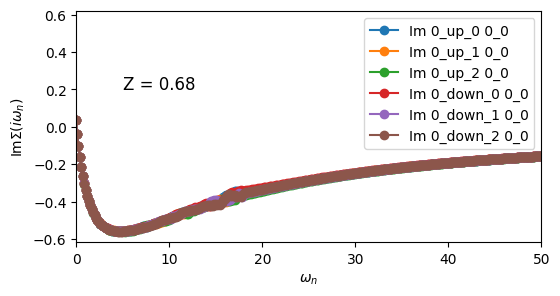

In [20]:
from h5 import HDFArchive
from triqs.plot.mpl_interface import oplot, plt
import numpy as np

with HDFArchive('srvo3/srvo3-beta=40-U=4.6-J=0.65.h5', 'r') as ar:
    last_iter = str(len(ar)-1)
    Sigma_iw  = ar[last_iter]['Sigma_imp_list'][0]

    mu = ar[last_iter]['mu']

beta = 40.0

Z = 1/(1 - Sigma_iw['up_0'][0,0](0).imag*beta/np.pi)

fig, ax = plt.subplots(figsize=(6,3))
ax.oplot(Sigma_iw.imag, 'o-'); ax.text(5, 0.2, f"Z = {round(Z,2)}", fontsize=12)
ax.set_ylabel(r'Im$\Sigma(i\omega_{n})$')
ax.set_xlim(0, 50)
plt.show()

The Mastsubara self-energy indicates metallic behavior with very small scattering rate ($\mathrm{Im}\Sigma(i\omega_{n}\rightarrow 0) \rightarrow 0$). We estimate a $Z$ of 0.68, which is slightly larger than experiment, but this could be due to our choice of interaction parameters as well as our method of estimating this quantity. We see that the thee V-$t_{2g}$ are degenerate as all curves collapse on top of each other as expected.

### 🧪 Exercise 6: Analytically continue the Matsubara self-energy

Now let's analytically contine the self-energy onto the real-axis so that we can plot real-frequency spectra. Use the maximum entropy utilities from before to analytically continue the self-energy from the last iteration. Plot your result.

In [33]:
from utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw, alpha_min=1e-2, alpha_max=1e2, error=0.01)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-11 08:35:45.146242
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.12393646154337133
scaling alpha by a factor 6151 (number of data points)
alpha[ 0] =   6.15100000e+05, chi2 =   6.93696933e+04, n_iter=       5 
alpha[ 1] =   5.09698170e+05, chi2 =   6.56194418e+04, n_iter=       3 
alpha[ 2] =   4.22357705e+05, chi2 =   6.15700631e+04, n_iter=       3 
alpha[ 3] =   3.49983659e+05, chi2 =   5.72610063e+04, n_iter=       4 
alpha[ 4] =   2.90011430e+05, chi2 =   5.27472299e+04, n_iter=       4 
alpha[ 5] =   2.40315876e+05, chi2 =   4.80977878e+04, n_iter=       4 
a

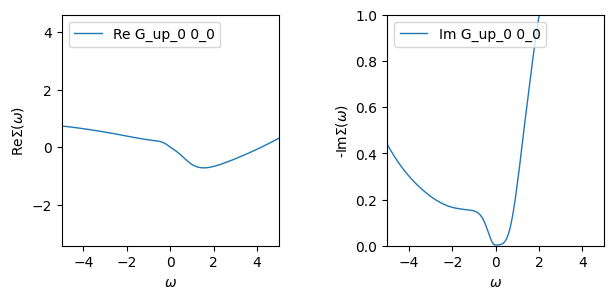

In [34]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(Sigma_w['up_0'] -Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1)
ax[1].oplot(-Sigma_w['up_0'].imag, lw=1)
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_xlim(-5,5); ax[1].set_ylim(0, 1); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 6: Compute real-frequency spectra
Now we plot the momentum-resolved spectral function along a high-symmetry path in the Brillouin zone. This is achieved by recomputing the Kohn-Sham eigenvalues and projectors along the high-symmetry path that we would like to see, then we compute the lattice Green's function along this path. The momentum-resolved spectral function corresponds to:
$$ A(\mathbf{k},\omega) = -\frac{1}{\pi}\mathrm{ImTr}G_{\nu\nu'}(\mathbf{k},\omega),$$
where the trace is over the band indices $\nu, \nu'$.

We have pre-computed the DFT data long the high-symmetry path R-$\Gamma$-X-M-$\Gamma$. This data is then converted using the Wien2kConverter (see [Tutorial 05](05s-dftdmft.ipynb) for more details).

#### 🧩 Your Task
1. Load in a new one-body elements using the function: ``one_body_elements_along_high_symmetry_path``.
2. Print out the new obe and try to spot any differences.
3. Embed your real-frequency self-energy using the Embedding (E).
4. Use the function ``spectral_function_on_high_symmetry_path`` to compute $A(k,\omega)$.

In [36]:
# load in obe along high-symmetry path

obe2 = modest.one_body_elements_on_high_symmetry_path('srvo3/srvo3.h5', obe)
print(obe2)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 21
      Represented on a fixed grid of 500 points.
      Shape of H[k_idx, σ, ν, ν'] = [500, 1, 21, 21]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 3
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   3
             a:   0
        irreps: [1, 1, 1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [500, 1, 3, 21]
  IBZ = false



In [41]:
# embed the self-energy
Sigma_C_w = E.embed([Sigma_w - Sigma_DC[0][0,0]])

In [43]:
# compute A(k,w)
Akw = modest.spectral_function_on_high_symmetry_path(obe2, mu, Sigma_C_w)

### 🧪 Exercise 7: Plot your result
Use the plot the script to plot your resulting $A(k,\omega)$.

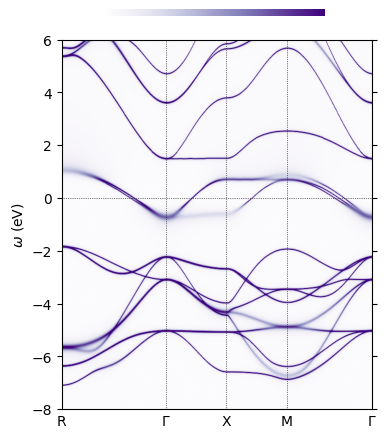

In [57]:
# matplotlib canvas and ticks
fig, ax = plt.subplots(figsize=(4,6))
ax.tick_params(right=True);ax.tick_params(which='both', axis='x', length=0)

# high-symmetry info printed in case.outband
high_kpts = [1,169,266,363,500]; high_labels = ['R', r'$\Gamma$', 'X', 'M', r'$\Gamma$']

# plot A(k,ω) using imshow
data = ax.imshow(Akw.data[0].T,origin='lower', cmap='Purples', aspect='auto', vmin=0, vmax=10, extent=(1,500, -10,10))

# create a colorbar
cbar = fig.colorbar(data, location='top', shrink=0.7, aspect=30)
cbar.set_ticks([]); cbar.outline.set_visible(False)

# decorate and set high-symmetry points
ax.set_xticks(high_kpts); ax.set_xticklabels(high_labels)
for k in high_kpts: ax.axvline(k, lw=0.5, ls='dotted', color='k')
ax.axhline(0.0, color='k', ls='dotted', lw=0.5)
ax.set_ylim(-8,6); ax.set_ylabel(r'$\omega$ (eV)')
plt.show()